#### Tests Seva-generated samples over the entire MV diffusion process.

1. Get data from dataloader.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import DataLoader
from sgm.data.dataset import DL3DVDataset
from seva.data.mvh_dataloader import MVHumanNetDataset


# dataset = DL3DVDataset(
#     dataset_dir="/workspace/leovol/dl3dv-480P-new",
#     colmap_dir="/workspace/leovol/dl3dv-colmap-new",
#     num_images=8,
#     latents_dir="/workspace/leovol/dl3dv-latents",
#     levels=["1K"]
# )

dataset = MVHumanNetDataset(
    dataset_dir="/home/stone/dev/datasets/mvh_net_samples",
    num_images=8,
    latents_dir="/home/stone/dev/datasets/mvh_net_samples/latents",
    levels=["1K"]
)

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)


2. Load Diffusion modules.

In [3]:
import math
from sgm.modules.autoencoding.temporal_ae import VideoDecoder
from seva.modules.autoencoder import AutoEncoder
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# helper functions
@torch.no_grad()
def encode_first_stage(x):
        n_samples = x.shape[0]
        n_rounds = math.ceil(x.shape[0] / n_samples)
        all_out = []
        with torch.autocast("cuda", enabled=False):
            for n in range(n_rounds):
                out = first_stage.encode(
                    x[n * n_samples : (n + 1) * n_samples]
                )
                all_out.append(out)
        z = torch.cat(all_out, dim=0)
        z = scale_factor * z
        return z

@torch.no_grad()
def decode_first_stage(z):
    # z = 1.0 / scale_factor * z -- VAE will do this automatically
    n_samples = z.shape[0]

    n_rounds = math.ceil(z.shape[0] / n_samples)
    all_out = []
    with torch.autocast("cuda", enabled=False):
        for n in range(n_rounds):
            if hasattr(first_stage, "decoder") and \
                isinstance(first_stage.decoder, VideoDecoder):
                kwargs = {"timesteps": len(z[n * n_samples : (n + 1) * n_samples])}
            else:
                kwargs = {}
            out = first_stage.decode(
                z[n * n_samples : (n + 1) * n_samples], **kwargs
            )
            all_out.append(out)
    out = torch.cat(all_out, dim=0)
    return out


def append_dims(x: torch.Tensor, target_dims: int) -> torch.Tensor:
    """Appends dimensions to the end of a tensor until it has target_dims dimensions."""
    dims_to_append = target_dims - x.ndim
    if dims_to_append < 0:
        raise ValueError(
            f"input has {x.ndim} dims but target_dims is {target_dims}, which is less"
        )
    return x[(...,) + (None,) * dims_to_append]

def tensor_to_image(t: torch.Tensor) -> torch.Tensor:
    # Convert [-1, 1] to [0, 1] for display
    t = (t + 1.0) / 2.0
    return t.clamp(0, 1)

def add_colored_border(img: torch.Tensor, color: tuple, border_width: int = 8):
    c, h, w = img.shape
    bordered = torch.ones(3, h + 2 * border_width, w + 2 * border_width)
    for i in range(3):
        bordered[i] *= color[i] / 255.0
    bordered[:, border_width:-border_width, border_width:-border_width] = img
    return bordered

def show_tensor_batch(images: torch.Tensor, frames: torch.Tensor=None, masks=None, nrow=4, border_width=8):
    """
    images: Tensor [B, 3, H, W] in [-1, 1] or [0, 1]
    masks: Optional Bool Tensor [B], True=red, False=blue
    """
    images = tensor_to_image(images)
    if frames is not None:
        frames = tensor_to_image(frames)
    print("images_min:", images.min(), "images_max:", images.max())

    if masks is not None:
        bordered_images = []
        for i, img in enumerate(images):
            img_ = img
            color = (247, 121, 132) if masks[i] else (101, 174, 219)
            if frames is not None and masks[i] == True: 
                img_ = frames[i]
            bordered_images.append(add_colored_border(img_, color, border_width))
        images = torch.stack(bordered_images)

    grid = torchvision.utils.make_grid(images, nrow=nrow, padding=16)
    npimg = grid.permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=(12, 6))
    plt.imshow(npimg)
    plt.axis('off')
    plt.show()



In [4]:
from seva.modules.conditioner import CLIPConditioner
from sgm.models.diffusion import DiffusionEngine
from sgm.modules.encoders.modules import GeneralConditioner
from sgm.modules.diffusionmodules.denoiser import DiscreteDenoiser
from sgm.modules.diffusionmodules.sampling import EulerEDMSampler
from sgm.modules.diffusionmodules.discretizer import LegacyDDPMDiscretization
from sgm.modules.diffusionmodules.denoiser_scaling import EpsScaling
from sgm.modules.diffusionmodules.guiders import VanillaCFG
from sgm.modules.encoders.modules import IdentityEncoder, SevaFrozenOpenCLIPImageEmbedder
from sgm.models.autoencoder import IdentityFirstStage
from seva.model import SGMWrapper
from sgm.util import instantiate_from_config
from seva.utils import load_model
from sgm.modules.diffusionmodules.wrappers import SevaWrapper, SevaWrapperV2
import seva.sampling as ss
from seva.modules.autoencoder import AutoEncoder
from seva.modules.lora_wrapper import SevaLoRAWrapper

import yaml
from omegaconf import OmegaConf


# ! ABOVE: SGM process (noisy!)
# Load the config file
# config_path = "configs/example_training/seva-true.yaml"
# config = OmegaConf.load(config_path)
# components_config = config.model.params

# # setup components from YAML config
# first_stage = instantiate_from_config(components_config.first_stage_config) # should stay IdentityFirstStage/DecoderOnly
# conditioner = instantiate_from_config(components_config.conditioner_config) # GeneralConditioner
# sampler = instantiate_from_config(components_config.sampler_config) # EulerEDMSampler (Seva implementation)
# denoiser = instantiate_from_config(components_config.denoiser_config).to("cuda") # SevaDiscreteDenoiser
# sigma_sampler = instantiate_from_config(components_config.loss_fn_config.params.sigma_sampler_config) # DiscreteSampling with DDPMDiscretization
# model = SevaWrapper(instantiate_from_config(components_config.network_config).eval()).to("cuda")

# use DDMPDiscretization over LegacyDDPM

# * BELOW: faithful Seva process
with torch.autocast("cuda"):
    ae = AutoEncoder(chunk_size=1).eval().to("cuda")
    conditioner = CLIPConditioner().to("cuda") # change this to GeneralConditioner with SevaFrozenOpenCLIPImageEmbedder and test for equality
    sampler = ss.EulerEDMSampler(
        discretization=ss.DDPMDiscretization(
            linear_start=5e-06,
            linear_end=0.012,
            num_timesteps=1000,
            log_snr_shift=2.4,
        ),
        guider=ss.MultiviewCFG(cfg_min=1.2),
        num_steps=50,
        s_churn=0.0,
        s_tmin=0.0,
        s_tmax=999.0,
        s_noise=1.0,
    )
    denoiser = ss.DiscreteDenoiser(
        discretization=ss.DDPMDiscretization(),
        num_idx=1000,
        device="cuda",
    )

    model = SGMWrapper( # swap to SevaWrapper during training
        instantiate_from_config(
            {
                "target": "seva.modules.lora_wrapper.SevaLoRAWrapper",
                "params": {
                    "seva_model_config": {
                        "target": "seva.utils.load_model",
                    },
                    "self_attn_rank": 4,
                    "cross_attn_rank": 8,
                    "alpha": 16.0,
                    "dropout": 0.0,
                    "target_modules": ["TransformerBlockTimeMix", "MultiviewTransformer", "TransformerBlock"],
                    "keys_to_lora": ["q", "k", "v"],
                }
            }
        )
    ).to("cuda")

scale_factor = 0.18215

layers of seva are FROZEN


torch.Size([8, 3, 576, 576])
images_min: tensor(0.) images_max: tensor(1.)


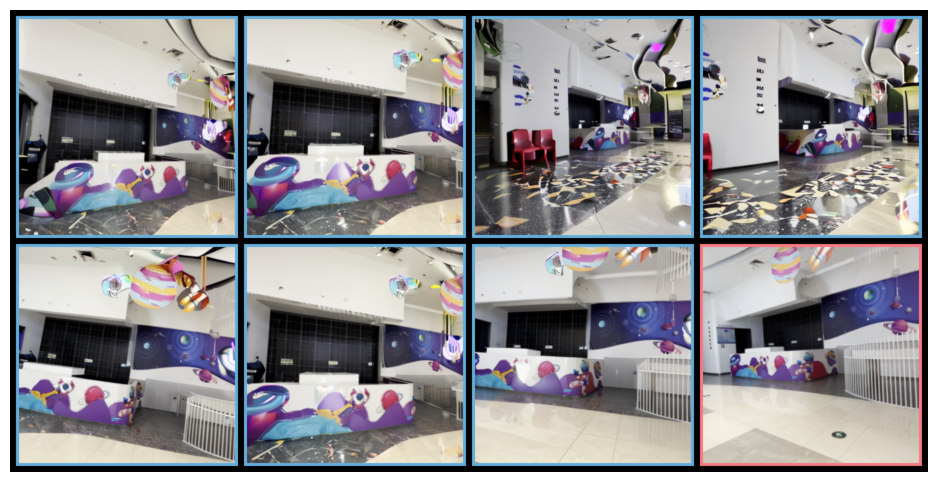

images_min: tensor(0.) images_max: tensor(0.9961)


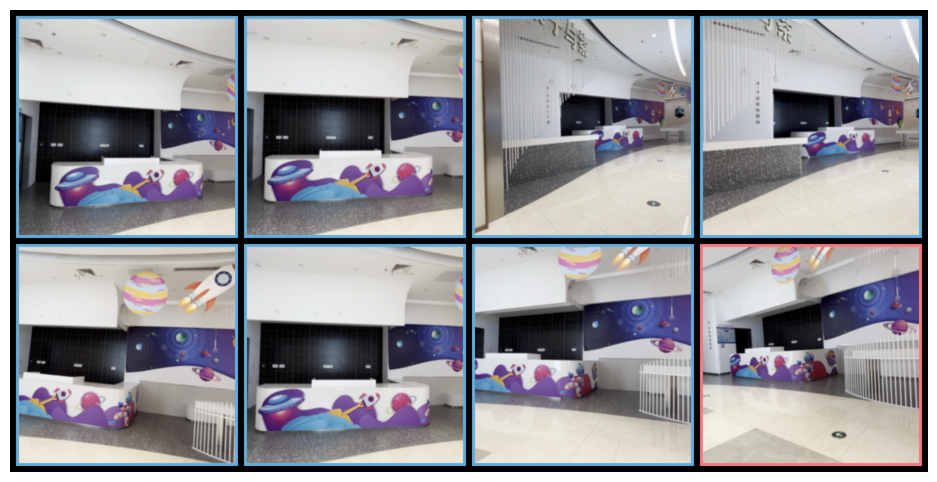

In [10]:
from einops import repeat

batch = next(iter(loader))

T = 8
batch = {k: v.to("cuda") for k, v in batch.items()}
input_masks = batch["mask"].reshape(T).to("cuda")
pluckers = batch["plucker"].reshape(T, 6, 72, 72).to("cuda")
clean_latent = batch["clean_latent"].to("cuda")
frames = batch["frames"].to("cuda")

with torch.inference_mode():
    latents = (clean_latent * scale_factor)
    latents = latents.reshape(T, 4, 72, 72)
    latents = torch.nn.functional.pad(
        latents, (0, 0, 0, 0, 0, 1), value=1.0
    )
    frames = frames.reshape(T, 3, 576,576)
    c_crossattn = repeat(conditioner(frames).mean(0), "d -> n 1 d", n=T) # T is # frames in context
    uc_crossattn = torch.zeros_like(c_crossattn)
    c_replace = latents.new_zeros(T, *latents.shape[1:])
    c_replace[input_masks] = latents[input_masks]
    uc_replace = torch.zeros_like(c_replace)
    c_concat = torch.cat(
        [
            repeat(
                input_masks,
                "n -> n 1 h w",
                h=pluckers.shape[2],
                w=pluckers.shape[3],
            ),
            pluckers,
        ],
        1,
    )
    uc_concat = torch.cat(
        [pluckers.new_zeros(T, 1, *pluckers.shape[-2:]), pluckers], 1
    )
    c_dense_vector = pluckers
    uc_dense_vector = c_dense_vector
    c = {
        "crossattn": c_crossattn,
        "replace": c_replace,
        "concat": c_concat,
        "dense_vector": c_dense_vector,
    }
    uc = {
        "crossattn": uc_crossattn,
        "replace": uc_replace,
        "concat": uc_concat,
        "dense_vector": uc_dense_vector,
    }

    additional_model_inputs = {"num_frames": T}
    
    # Update the dictionaries with moved tensors
    c = {
        "crossattn": c_crossattn,
        "replace": c_replace,
        "concat": c_concat,
        "dense_vector": c_dense_vector,
    }
    uc = {
        "crossattn": uc_crossattn,
        "replace": uc_replace,
        "concat": uc_concat,
        "dense_vector": uc_dense_vector,
    }

    randn = torch.randn(T, 4, 72, 72).to("cuda")
    samples_z = sampler(
        lambda input, sigma, c: denoiser(
            model,
            input,
            sigma,
            c,
            **additional_model_inputs,
        ),
        randn,
        scale=2.0, #cfg
        cond=c,
        uc=uc,
        **{"c2w": batch["c2ws"].reshape(T,4,4).to("cuda"),
        "K": batch["Ks"].reshape(T,3,3).to("cuda"),
        "input_frame_mask": input_masks.to("cuda")},
    )
    samples = ae.decode(samples_z, chunk_size=1)
print(samples.shape)
show_tensor_batch(samples.to("cpu"), masks=input_masks.to("cpu"))
show_tensor_batch(frames.to("cpu"), masks=input_masks.to("cpu"))

In [6]:
# def run_one_scene(model, conditioner, sigma_sampler, denoiser, batch):
#     with torch.no_grad():
#         inputs = batch["clean_latent"]
#         latents = encode_first_stage(inputs) # * scale_factor (internally)
#         # latents = latents.reshape(-1, *latents.shape[2:])
#         # condition
#         cond = conditioner(batch)
#         # sample
#         sigmas = sigma_sampler(latents.shape[0]).to(latents)
#         noise = torch.randn_like(latents)
#         sigmas_bc = append_dims(sigmas, latents.ndim)
#         noised_input = latents + noise * sigmas_bc

#         print("inputs.shape:", inputs.shape)
#         print("latents.shape:", latents.shape)
#         print("cond.keys:", cond.keys())

#         sigmas = sigmas.to("cuda")
#         latents = latents.to("cuda")
#         noised_input = noised_input.to("cuda")
#         cond = {k: v.to("cuda") for k, v in cond.items()}

#         model_output = denoiser(
#             model, noised_input, sigmas, cond
#         )

#         outputs = decode_first_stage(model_output).detach()
#     return outputs

In [7]:
# batch = next(iter(loader))
# vae = AutoEncoder().eval().to("cuda")
# output_latents = run_one_scene(model, conditioner, sigma_sampler, denoiser, batch)
# rgb_outputs = vae.decode(output_latents.view(-1, *output_latents.shape[2:])).to("cpu")
# gt_images = batch["frames"].view(-1, *batch["frames"].shape[2:])

# masks = batch["mask"].reshape(-1)
# show_tensor_batch(rgb_outputs, masks=masks)
# show_tensor_batch(gt_images, frames=batch["frames"].view(-1, *batch["frames"].shape[2:]), masks=masks)


- VAE expects (T,3,H,W) => (T,4,72,72)
encodings are padded to (T,5,72,72)
conditioner expects (T,3,H,W), then take the mean(dim=0)
- crossattn => (T,1,1024)
- concat => (T,7,72,72)
- replace => (T,5,72,72) masked
- dense_vector(plucker) expects (T,6,72,72)
rand noise => (T,4,72,72)
guider_kwargs in EulerEDMSampler:
c2w (T,4,4), K (21,3,3), mask(21,)

In [8]:
torch.cuda.empty_cache()